# Chapter 8: From Discovery to Defensible Findings

A weak region found by search has been measured on the data that guided the search, and those measurements are biased toward the regions the search preferred. Chapter 8 describes how a discovery becomes a defensible finding: the rule is frozen, it is measured on independent observations, its uncertainty is stated for the whole family of reported claims and every frozen result is retained. This notebook applies that procedure to the medoid-search study of Chapters 1, 3 and 4.

The notebook loads the confirmation observations and frozen membership masks, recomputes the thirteen regional findings and compares them with their discovery values, recomputes the six paired comparisons with their shared-observation uncertainty and checks the declared family of nineteen claims. No model is fitted and no language model is called.

**Evidence.** The records are in `book/evidence/aml_medoid_loop_leaf_output_20260921/`: 200,000 confirmation observations drawn with seed 62491 after all selections froze, with saved predictions and membership masks. The population is synthetic, and Chapter 2's corrected geometry belongs to a different run.

**Run order.** Run the cells from top to bottom. Each assertion checks a recomputed quantity against the saved results or the chapter.

## Setup and source checks

Use a Python kernel with the dependencies listed in the README. The setup cell locates the data root, which holds the evidence files and helper modules. It uses `MODEL_VALIDATION_ROOT` when that variable is set. Otherwise it searches for a repository checkout containing the current directory and then for the copy installed with the `aiv` package.

`load()` reads the protocol, confirmation results and frozen finalists and checks the SHA-256 digests that link them. `confirmation` and `measure` are the helper functions used in Chapter 1 to read the confirmation sample and compute a region's contrast with its influence-function standard error.

In [1]:
from pathlib import Path
import os
import platform
import sys
import importlib.util

# Locate the data root: the directory whose relative layout the evidence records use.
MARKER = "book/notebooks/regional_case/companion.py"

def find_data_root():
    configured = os.environ.get("MODEL_VALIDATION_ROOT")
    if configured:
        root = Path(configured).expanduser().resolve()
        if not (root / MARKER).is_file():
            raise FileNotFoundError(f"MODEL_VALIDATION_ROOT must contain {MARKER}")
        return root, "MODEL_VALIDATION_ROOT"
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / MARKER).is_file():
            return path, "repository checkout"
    try:
        from aiv.companions import locate
    except ImportError:
        raise FileNotFoundError(
            "Companion data not found. Install the aiv package, open the notebook "
            "inside the repository checkout, or set MODEL_VALIDATION_ROOT.") from None
    return locate()

ROOT, DATA_SOURCE = find_data_root()
HELPERS = ROOT / "book/notebooks/regional_case"
for path in (ROOT, ROOT / "book", HELPERS):
    value = str(path)
    if value in sys.path:
        sys.path.remove(value)
    sys.path.insert(0, value)

# Load current helper files even if this kernel cached an older notebook revision.
def load_helper_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    try:
        spec.loader.exec_module(module)
    except Exception:
        sys.modules.pop(name, None)
        raise
    return module

load_helper_module("companion", HELPERS / "companion.py")
load_helper_module("ch02_helpers", HELPERS / "ch02_helpers.py")
load_helper_module("weighted_leaf_geometry", ROOT / "book/weighted_leaf_geometry.py")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
print("Python:", platform.python_version())
print("Data root found from:", DATA_SOURCE)
from companion import RUN, read, load, frontier, confirmation, measure, assignments
pd.set_option("display.float_format", "{:.6f}".format)
protocol, results, frozen = load()
print("Evidence:", RUN.relative_to(ROOT))
print("Mode: saved-evidence replay; no fitting or live LLM calls")


Python: 3.12.3
Data root found from: repository checkout
Evidence: book/evidence/aml_medoid_loop_leaf_output_20260921
Mode: saved-evidence replay; no fitting or live LLM calls


## Load frozen evidence

A region found by adaptive search is a hypothesis until it is measured on observations that played no part in finding it (Section 8.1). Confirmation therefore requires two things: the rule must be frozen before the confirmation data exist, and every frozen rule must be reported, whether or not its result is favorable (Section 8.2). In this study every arm's primary selection was frozen, and only then were 200,000 confirmation observations generated with seed 62491.

`confirmation()` returns the Brier loss $L_i=(y_i-p_i)^2$ of each confirmation observation under the frozen logistic predictor, and a membership mask for every frozen region. Each mask was computed from the observation's features alone by the frozen assignment that Chapter 1 replayed. The cell checks that every finalist has a mask and that the sample size matches the protocol, then lists the finalists.

In [2]:
loss,masks=confirmation()
keys=[c["key"] for c in frozen["finalists"]]
assert set(keys)<=set(masks) and len(loss)==protocol["confirmation_n"]
print("Confirmation rows:",len(loss),"| seed:",protocol["confirmation_seed"])
print("Frozen finalists:",len(keys))
print(keys)

Confirmation rows: 200000 | seed: 62491
Frozen finalists: 13
['twinning_73101', 'random_73101', 'continuation_73101', 'reflection_73101', 'twinning_73102', 'random_73102', 'continuation_73102', 'reflection_73102', 'twinning_73103', 'random_73103', 'continuation_73103', 'reflection_73103', 'pam']


**Read the output.** Thirteen frozen regions enter confirmation: the subset-PAM reference and the twinning, random, continuation and reflection arms at each of three optimizer seeds. All thirteen are measured and reported below. None of them is chosen or discarded on the basis of these outcomes, which is what distinguishes confirmation from a further round of discovery.

## Recompute each finding

For each frozen region the cell recomputes the confirmation measurements from the saved observations with `measure`, as Chapter 1 did for one region: the member count and share, the regional and remaining mean Brier loss, their contrast, the influence-function standard error and the simultaneous interval with the study's critical value. The assertion requires every recomputed field to equal the saved result.

The second table places each region's discovery contrast, taken from its frozen record, beside its confirmation contrast. Section 8.1 explains why the discovery value of a selected candidate tends to be too high: each arm kept the largest contrast among many noisy estimates, and the largest of several estimates is biased upward even when each one is unbiased.

In [3]:
influences={};rows=[]
for key in keys:
    stats,influences[key]=measure(loss,masks[key],results["critical_value"])
    for field,value in stats.items():np.testing.assert_allclose(value,results["confirmation"][key][field],rtol=1e-12,atol=1e-12)
    lo,hi=stats.pop("simultaneous_ci")
    rows.append(dict(candidate=key,**stats,ci_lower=lo,ci_upper=hi))
findings=pd.DataFrame(rows).set_index("candidate")
display(findings)
discovery={c["key"]:c["discovery"]["region"] for c in frozen["finalists"]}
optimism=pd.DataFrame({"discovery_contrast":[discovery[k]["contrast"] for k in findings.index],
                       "confirmation_contrast":findings["contrast"]},index=findings.index)
optimism["discovery_minus_confirmation"]=optimism.discovery_contrast-optimism.confirmation_contrast
display(optimism)
print("Regions with discovery contrast above confirmation:",int((optimism.discovery_minus_confirmation>0).sum()),"of",len(optimism))

,n,share,brier,rest_brier,contrast,standard_error,ci_lower,ci_upper
candidate,,,,,,,,
twinning_73101,22785,0.113925,0.072584,0.014645,0.057940,0.001525,0.053351,0.062528
random_73101,28075,0.140375,0.062941,0.014437,0.048504,0.001306,0.044576,0.052432
continuation_73101,22785,0.113925,0.072584,0.014645,0.057940,0.001525,0.053351,0.062528
reflection_73101,23044,0.115220,0.072851,0.014525,0.058326,0.001519,0.053757,0.062894
twinning_73102,24621,0.123105,0.068592,0.014599,0.053993,0.001454,0.049619,0.058368
random_73102,20694,0.103470,0.080225,0.014439,0.065786,0.001679,0.060737,0.070835
continuation_73102,20010,0.100050,0.073065,0.015484,0.057581,0.001647,0.052628,0.062533
reflection_73102,24621,0.123105,0.068592,0.014599,0.053993,0.001454,0.049619,0.058368
twinning_73103,24626,0.123130,0.066468,0.014895,0.051573,0.001444,0.047230,0.055915


,discovery_contrast,confirmation_contrast,discovery_minus_confirmation
candidate,,,
twinning_73101,0.061616,0.057940,0.003677
random_73101,0.048506,0.048504,0.000002
continuation_73101,0.061616,0.057940,0.003677
reflection_73101,0.064412,0.058326,0.006087
twinning_73102,0.057295,0.053993,0.003302
random_73102,0.065410,0.065786,-0.000376
continuation_73102,0.064158,0.057581,0.006577
reflection_73102,0.057295,0.053993,0.003302
twinning_73103,0.060556,0.051573,0.008983


Regions with discovery contrast above confirmation: 12 of 13


**Read the output.** All thirteen findings reproduce the saved values. Every interval lies above zero, so each frozen region has elevated Brier loss relative to the rest of the confirmation sample under the stated conditions; the smallest contrast is the PAM reference's 0.041112 and the largest random_73103's 0.073208. The discovery contrast exceeds the confirmation contrast for 12 of the 13 regions, by up to 0.008983 for twinning_73103, and random_73102 is the only region whose confirmation contrast is higher, by 0.000376. This pattern is consistent with the selection optimism described in Section 8.1. Some rows are identical because two arms froze the same region: continuation at seed 73101 and reflection at seed 73102 both kept the twinning run's selection.

## Preserve pairing

The study's comparative claims concern pairs of arms within a seed: reflection against continuation, and twinning against random initialization. Both regions of a pair are measured on the same 200,000 observations, so their estimation errors are correlated. Treating them as independent would overstate the variance of the difference. The paired standard error instead uses the difference of the two influence functions computed on each observation,

$$\widehat{\mathrm{se}}(\hat\Delta_a-\hat\Delta_b)=\frac{\operatorname{sd}(\psi^{(a)}-\psi^{(b)})}{\sqrt n},$$

which removes the variation the two regions share. The cell recomputes the six prespecified differences and their simultaneous intervals, asserts that they match the saved values and plots them with a vertical line at zero.

,comparison,seed,difference,ci_lower,ci_upper
0,reflection minus continuation,73101,0.000386,-0.001723,0.002495
1,twinning minus random,73101,0.009436,0.005746,0.013125
2,reflection minus continuation,73102,-0.003587,-0.007844,0.000669
3,twinning minus random,73102,-0.011793,-0.016765,-0.006821
4,reflection minus continuation,73103,0.002373,-0.000913,0.005660
5,twinning minus random,73103,-0.021636,-0.025933,-0.017338


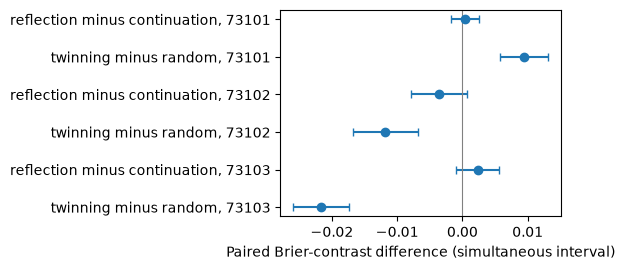

In [4]:
rows=[]
for c in results["comparisons"]:
    a=f"{c['a']}_{c['seed']}";b=f"{c['b']}_{c['seed']}"
    delta=results["confirmation"][a]["contrast"]-results["confirmation"][b]["contrast"]
    se=(influences[a]-influences[b]).std(ddof=1)/np.sqrt(len(loss))
    ci=[delta-results["critical_value"]*se,delta+results["critical_value"]*se]
    np.testing.assert_allclose(ci,c["simultaneous_ci"],rtol=1e-12,atol=1e-12)
    rows.append(dict(comparison=f"{c['a']} minus {c['b']}",seed=c["seed"],difference=delta,ci_lower=ci[0],ci_upper=ci[1]))
paired=pd.DataFrame(rows)
display(paired)
fig,ax=plt.subplots(figsize=(6,2.8))
y=np.arange(len(paired))[::-1]
ax.errorbar(paired["difference"],y,xerr=[paired["difference"]-paired["ci_lower"],paired["ci_upper"]-paired["difference"]],fmt="o",capsize=3)
ax.axvline(0,color="gray",lw=.8)
ax.set_yticks(y,[f"{r.comparison}, {r.seed}" for r in paired.itertuples()])
ax.set_xlabel("Paired Brier-contrast difference (simultaneous interval)")
plt.tight_layout();plt.show()

**Read the output.** The three reflection-minus-continuation intervals all contain zero, so the structural revision has no resolved advantage over continuation at any seed. The three twinning-minus-random intervals all exclude zero, but in different directions: twinning is higher at seed 73101 and random initialization at seeds 73102 and 73103. The three seeds share one discovery sample and one confirmation sample, so the mixed initialization results describe search variation under common inputs.

## Check the declared family

Nineteen claims are reported: the 13 regional contrasts and the six paired differences. If each had its own 95% interval, the probability that at least one misses its target could greatly exceed 5% (Section 8.5). The Bonferroni correction assigns each claim a two-sided error of $0.05/19$, giving the critical value $z=\Phi^{-1}(1-0.05/38)$, so that all 19 intervals hold together with probability at least 95% under the normal approximation.

The cell checks the family size and critical value, checks the confirmation contrasts that the chapter quotes and displays the three structural comparisons with their zero-inclusion flags.

In [5]:
from scipy.stats import norm
assert results["family_size"]==len(findings)+len(paired)==19
np.testing.assert_allclose(results["critical_value"],norm.ppf(1-.05/(2*19)),rtol=1e-12)
print("Family size:",results["family_size"],"| Bonferroni critical value:",round(results["critical_value"],6))
quoted={"twinning_73101":.057940,"twinning_73102":.053993,"twinning_73103":.051573,"pam":.041112}
for key,value in quoted.items():assert round(findings.loc[key,"contrast"],6)==value
reflection=paired[paired.comparison=="reflection minus continuation"]
assert [round(v,6) for v in reflection["difference"]]==[.000386,-.003587,.002373]
assert ((reflection.ci_lower<=0)&(0<=reflection.ci_upper)).all()
display(reflection.assign(includes_zero=True))

Family size: 19 | Bonferroni critical value: 3.007787


,comparison,seed,difference,ci_lower,ci_upper,includes_zero
0,reflection minus continuation,73101,0.000386,-0.001723,0.002495,True
2,reflection minus continuation,73102,-0.003587,-0.007844,0.000669,True
4,reflection minus continuation,73103,0.002373,-0.000913,0.005660,True


**Read the output.** The family contains 13 regional summaries and six paired comparisons, and the critical value 3.007787 matches $\Phi^{-1}(1-0.05/38)$. The quoted contrasts and the three structural differences agree with the recomputed values. These are approximate simultaneous intervals conditional on the fitted predictor, the auxiliary model and the frozen regions. They quantify sampling variation in the confirmation sample. They do not describe variation across repeated runs of the entire pipeline, which would also redraw the discovery sample, refit the auxiliary model and repeat the searches.

## What the replay establishes

All thirteen frozen regions and six prespecified comparisons have been recomputed from the confirmation observations under one declared family. Each region shows elevated Brier loss on new observations, and the discovery contrasts were optimistic for 12 of the 13. The structural revision shows no resolved advantage over continuation, while the initialization comparison favors different arms at different seeds.

These findings concern the frozen predictor in a synthetic population. They establish where its probability error is concentrated. They do not establish why, whether the region matters operationally or whether retraining would reduce the error; those questions belong to attribution, materiality and remediation (Sections 8.6 and 8.7). Chapter 9 assembles these findings into a report and checks the report against the evidence.


## What to try

1. **Coverage.** For random_73103, compare discovery share 0.1008 with confirmation share. Explain why a region selected just above a 10% discovery floor can fall below 10% on confirmation, and why its membership is not adjusted.
2. **Unpaired error.** For reflection minus continuation at seed 73101, compute the standard error of the difference as if the two regions were independent, $\sqrt{\mathrm{se}_a^2+\mathrm{se}_b^2}$. Compare it with the paired standard error and explain the difference.
3. **Family size.** Recompute the six paired intervals with an unadjusted 95% critical value, 1.959964. State which conclusions change and why reporting them would misstate the evidence.
4. **Independent studies.** Explain why three optimizer seeds sharing one discovery and one confirmation sample are not three independent studies, and describe what a replication would need to redraw.
